In [1]:
from datascience import *
import numpy as np

%matplotlib inline
import matplotlib.pyplot as plt
plt.style.use('fivethirtyeight')

In [2]:
births = Table.read_table('data/baby.csv')
births

Birth Weight,Gestational Days,Maternal Age,Maternal Height,Maternal Pregnancy Weight,Maternal Smoker
120,284,27,62,100,False
113,282,33,64,135,False
128,279,28,64,115,True
108,282,23,67,125,True
136,286,25,62,93,False
138,244,33,62,178,False
132,245,23,65,140,False
120,289,25,62,125,False
143,299,30,66,136,True
140,351,27,68,120,False


In [4]:
smoking_and_birth_weight = births.select('Maternal Smoker', 'Birth Weight')
smoking_and_birth_weight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [ ]:
# Crushed ICE:
# 1. get the # of babies born t omothers who smoked & mothers who did not smoke
# 2. get the avg. birth weights of each group

In [5]:
smoking_and_birth_weight.group('Maternal Smoker')

Maternal Smoker,count
False,715
True,459


In [6]:
smoking_and_birth_weight.group('Maternal Smoker', np.average)

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


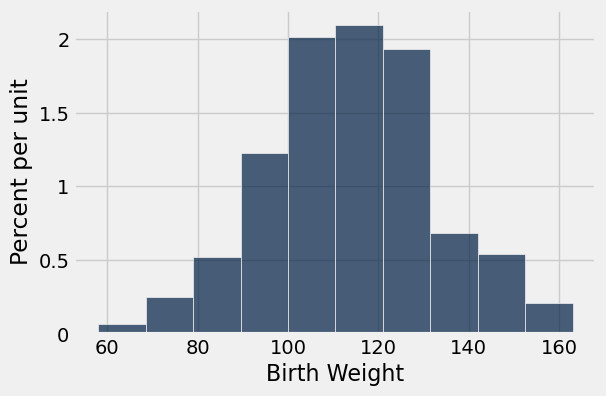

In [8]:
smoking_and_birth_weight.where('Maternal Smoker', True).hist('Birth Weight')

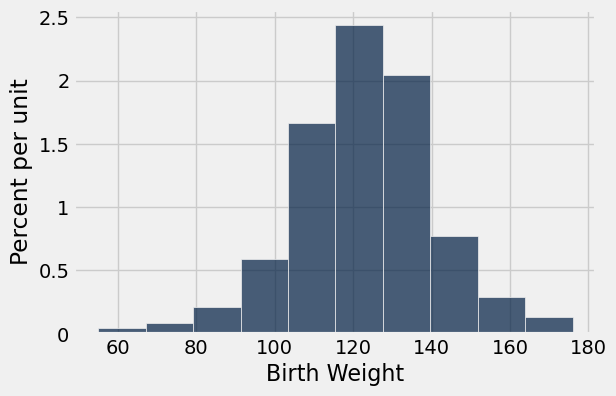

In [9]:
smoking_and_birth_weight.where('Maternal Smoker', False).hist('Birth Weight')

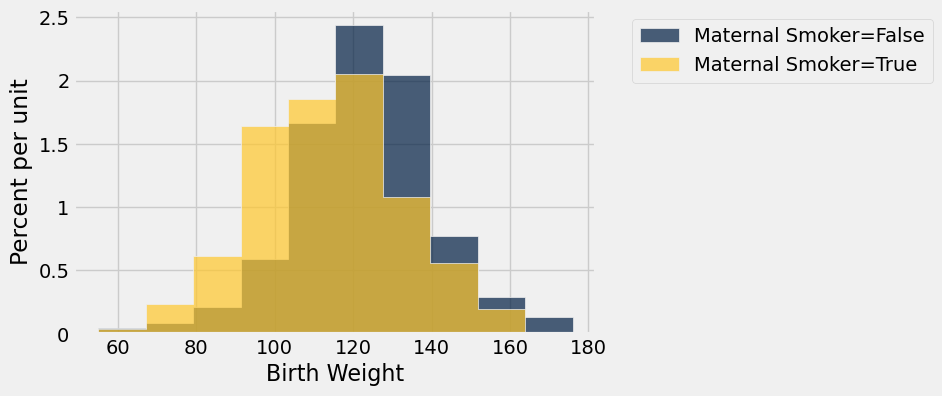

In [10]:
smoking_and_birth_weight.hist('Birth Weight', group='Maternal Smoker')

In [12]:
means_table = smoking_and_birth_weight.group('Maternal Smoker', np.average)
means_table

Maternal Smoker,Birth Weight average
False,123.085
True,113.819


In [15]:
means = means_table.column(1)
observed_difference = means.item(1) - means.item(0)
observed_difference

-9.266142572024918

In [16]:
smoking_and_birth_weight

Maternal Smoker,Birth Weight
False,120
False,113
True,128
True,108
False,136
False,138
False,132
False,120
True,143
False,140


In [17]:
smoking_and_birth_weight.sample(smoking_and_birth_weight.num_rows, with_replacement=False)

Maternal Smoker,Birth Weight
True,139
True,125
True,91
True,140
True,124
True,122
True,103
False,113
False,115
False,143


In [25]:
shuffled_labels = smoking_and_birth_weight.sample(smoking_and_birth_weight.num_rows, with_replacement=False).column(0)
original_and_shuffled = smoking_and_birth_weight.with_column('Shuffled Label', shuffled_labels)
original_and_shuffled

Maternal Smoker,Birth Weight,Shuffled Label
False,120,False
False,113,False
True,128,False
True,108,False
False,136,False
False,138,False
False,132,False
False,120,False
True,143,False
False,140,False


In [28]:
shuffled_only = original_and_shuffled.select('Birth Weight', 'Shuffled Label')
shuffled_group_means = shuffled_only.group('Shuffled Label', np.average)
shuffled_group_means

Shuffled Label,Birth Weight average
False,119.197
True,119.876


In [29]:
def difference_of_means(table, group_label):
    reduced = table.select('Birth Weight', group_label)
    shuffled_group_means = reduced.group(group_label, np.average)
    means = shuffled_group_means.column(1)
    observed_difference = means.item(1) - means.item(0)
    return observed_difference

In [30]:
difference_of_means(original_and_shuffled, 'Maternal Smoker')

-9.266142572024918

In [31]:
difference_of_means(original_and_shuffled, 'Shuffled Label')

0.6786141962612646

In [32]:
def one_simulated_difference_of_means():
    # array of shuffled labels
    shuffled_labels = smoking_and_birth_weight.sample(smoking_and_birth_weight.num_rows, with_replacement=False).column(0)

    # table with birth weights and shuffled labels
    original_and_shuffled = smoking_and_birth_weight.with_column('Shuffled Label', shuffled_labels)

    return difference_of_means(original_and_shuffled, 'Shuffled Label')

In [46]:
one_simulated_difference_of_means()

-0.9561893444246437

In [47]:
differences = make_array()

repetitions = 5000
for i in np.arange(repetitions):
    differences = np.append(differences, one_simulated_difference_of_means())

differences

array([ 1.89130216,  0.03470908,  0.01682283, ..., -0.10838094,
        0.78950897,  0.67503695])

In [48]:
# Crushed ICE: generate a histogram of these differences and compare it to our observed_difference
# Generate a p-value if you can!

Observed Difference: -9.266142572024918


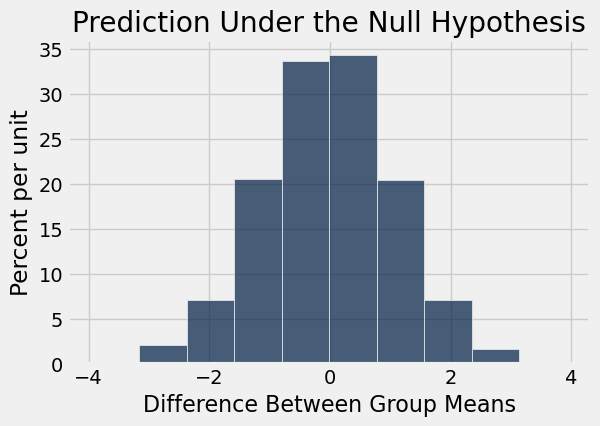

In [51]:
Table().with_column('Difference Between Group Means', differences).hist()
plt.title('Prediction Under the Null Hypothesis')
print('Observed Difference:', observed_difference)

In [54]:
empirical_p = np.count_nonzero(differences <= observed_difference) / repetitions
empirical_p

0.0

---

# Super Soda

In [2]:
sample_proportions(200, [0.5, 0.5])

array([ 0.565,  0.435])

In [9]:
np.count_nonzero(np.random.choice(make_array('H', 'T'), 200) == 'H')

98

In [11]:
def simulate_one_count(sample_size):
    return np.count_nonzero(np.random.choice(make_array('H', 'T'), sample_size) == 'H')

simulate_one_count(200)

114

In [12]:
num_simulations = 10000
counts = make_array()

for i in np.arange(num_simulations):
    counts = np.append(counts, simulate_one_count(200))

counts

array([ 106.,   94.,   96., ...,  105.,   83.,  107.])

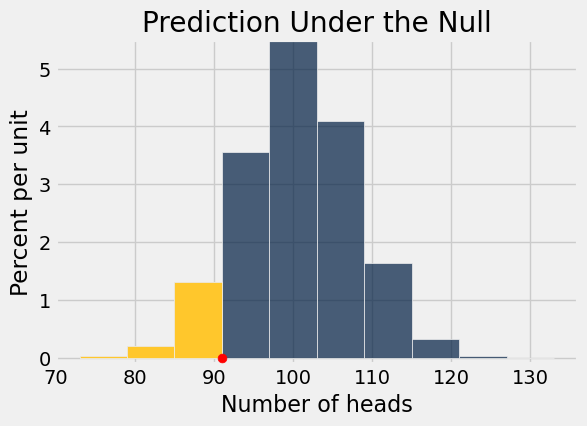

In [13]:
trials = Table().with_column('Number of heads', counts)
trials.hist(right_end=91)
plt.ylim(-0.001, 0.055)
plt.scatter(91, 0, color='red', s=40, zorder=3)
plt.title('Prediction Under the Null');

In [17]:
np.count_nonzero(counts <= 91) / len(counts)

0.117

In [ ]:
# Conclusion: we do not reject the null hypothesis.
# If you were the manufacturer, you'd probably try a bigger sample to confirm that it was just random chance!

## Changing the number of simulations

In [54]:
# Keeping the data fixed, we can re-run the test with a new simulation under the null
def run_test(num_simulations, sample_size):
    counts = make_array()
    for i in np.arange(num_simulations):
        counts = np.append(counts, simulate_one_count(sample_size))
    return counts

counts = run_test(10000, 200)
np.count_nonzero(counts <= 91)/len(counts)

0.1074

In [43]:
# Let's repeat that 50 times for each number of simulations
tests = Table(['simulations', 'p-value for 91'])
for num_sims in [100, 1000, 10000]:
    for k in np.arange(50):
        counts = run_test(num_sims, 200)
        tests = tests.with_row([
            num_sims, 
            np.count_nonzero(counts <= 91)/len(counts),
        ])
tests.sample(10)

simulations,p-value for 91
1000,0.103
100,0.12
1000,0.125
10000,0.1165
1000,0.125
10000,0.112
1000,0.113
10000,0.1121
1000,0.113
10000,0.1124


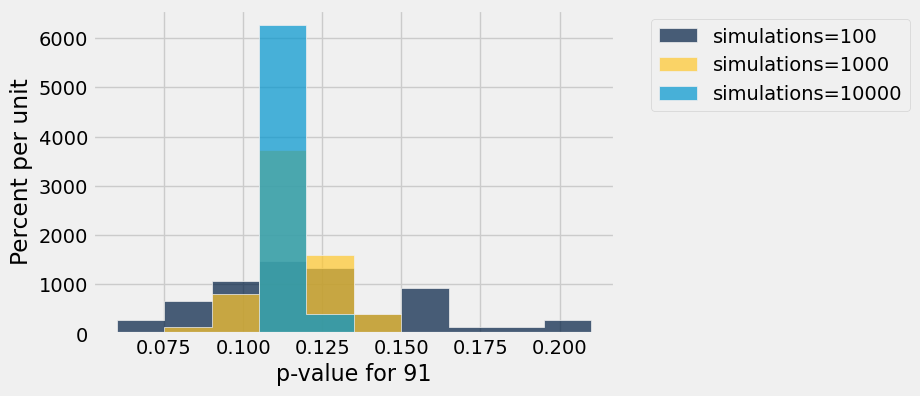

In [44]:
# For larger numbers of simulations, p-values are more consistent
tests.hist(1, group='simulations')

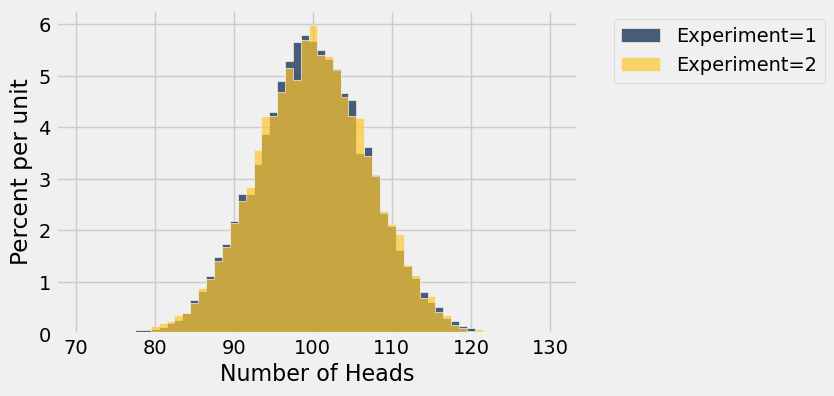

In [58]:
# A large number of simulations provides a good estimate of the
# theoretical distribution of the test statistic under the null hypothesis
num_sims = 10000 # let's try 100, 1000, and 10000
counts_1 = run_test(num_sims, 200)
counts_2 = run_test(num_sims, 200)
t = Table().with_columns(
    'Experiment', [1] * num_sims + [2] * num_sims,
    'Number of Heads', np.append(counts_1, counts_2))
t.hist(1, group='Experiment', bins=np.arange(70.5, 131, 1))

## Changing the size of the taste test

In [59]:
# Suppose that the true proportion of people who prefer Super Soda is...
true_proportion = 0.5 # we'll try both 0.5 and 0.4 below
true_distribution = make_array(true_proportion, 1 - true_proportion)
true_distribution

array([ 0.5,  0.5])

In [65]:
# Taste tests with 200 people will give various numbers of people who prefer Super Soda
sample_size = 200
sample_proportions(sample_size, true_distribution) * sample_size

array([ 105.,   95.])

In [76]:
# If you run a taste test for 200 people, what might you conclude?
def run_experiment(num_simulations, sample_size, true_proportion):
    # Collect data
    true_distribution = make_array(true_proportion, 1 - true_proportion)
    taste_test_results = sample_proportions(sample_size, true_distribution) * sample_size
    observed_stat_from_this_sample = taste_test_results.item(0)
    
    # Perform hypothesis test
    counts = run_test(num_simulations, sample_size)
    p_value = np.count_nonzero(counts <= observed_stat_from_this_sample) / len(counts)
    return p_value

run_experiment(10000, 200, 0.5)

0.2176

1.0

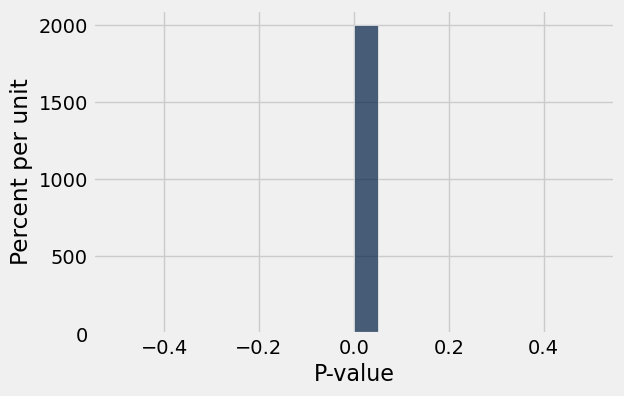

In [80]:
# Let's imagine running our taste test over and over again to see how often we reject the null
# Assume there really is a difference (0.4 vs 0.6)
# Let's try sample sizes of: 100, 200, and 1000
true_proportion = 0.4
sample_size = 1000
p_values = make_array()
for k in np.arange(100):
    p_value = run_experiment(1000, sample_size, true_proportion)
    p_values = np.append(p_values, p_value)
Table().with_column('P-value', p_values).hist(0, bins=20)

np.count_nonzero(p_values <= 0.05) / len(p_values)

# Titanic

In [18]:
titanic = Table.read_table('data/titanic.csv')
titanic

PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,0,3,"Braund, Mr. Owen Harris",male,22,1,0,A/5 21171,7.25,nan,S
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38,1,0,PC 17599,71.2833,C85,C
3,1,3,"Heikkinen, Miss. Laina",female,26,0,0,STON/O2. 3101282,7.925,nan,S
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35,1,0,113803,53.1,C123,S
5,0,3,"Allen, Mr. William Henry",male,35,0,0,373450,8.05,nan,S
6,0,3,"Moran, Mr. James",male,nan,0,0,330877,8.4583,nan,Q
7,0,1,"McCarthy, Mr. Timothy J",male,54,0,0,17463,51.8625,E46,S
8,0,3,"Palsson, Master. Gosta Leonard",male,2,3,1,349909,21.075,nan,S
9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27,0,2,347742,11.1333,nan,S
10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14,1,0,237736,30.0708,nan,C


In [19]:
titanic2 = titanic.select('Sex', 'Survived')
titanic2

Sex,Survived
male,0
female,1
female,1
female,1
male,0
male,0
male,0
male,0
female,1
female,1


In [21]:
titanic2.group('Sex', np.average)

Sex,Survived average
female,0.742038
male,0.188908


In [22]:
titanic2.sample(titanic2.num_rows, with_replacement=False) # you can omit titanic2.num_rows--that's the default

Sex,Survived
female,1
female,1
male,0
male,0
female,1
male,0
male,0
female,1
female,0
female,1


In [26]:
titanic2.with_column(
    'Shuffled Label', titanic2.sample(with_replacement=False).column('Sex')
).group('Shuffled Label', np.average)

Shuffled Label,Sex average,Survived average
female,,0.394904
male,,0.377816


In [38]:
titanic2.with_column(
    'Shuffled Label', titanic2.sample(with_replacement=False).column('Sex')
).group('Shuffled Label', np.average).column(2).item(0)

0.3662420382165605

In [40]:
def one_simulated_rate():
    averages = titanic2.with_column(
        'Shuffled Label', titanic2.sample(with_replacement=False).column('Sex')
    ).group('Shuffled Label', np.average)
    return averages.column(2).item(0)

one_simulated_rate()

0.36942675159235666

0.0

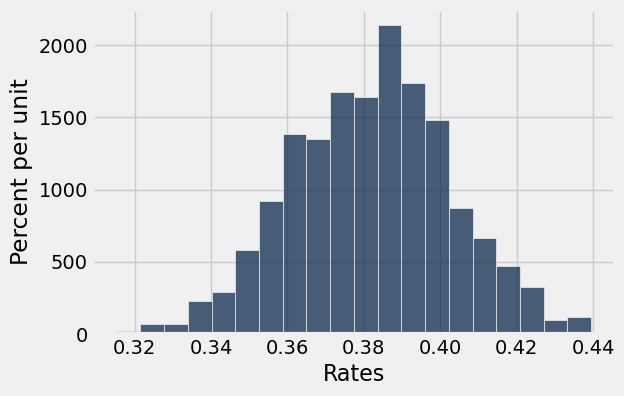

In [41]:
simulations = 1000
simulated_rates = make_array()
for i in np.arange(simulations):
    simulated_rates = np.append(simulated_rates, one_simulated_rate())

Table().with_column('Rates', simulated_rates).hist(0, bins=20)

np.count_nonzero(simulated_rates >= 0.742038) / len(simulated_rates)

# Fish Diet

In [83]:
fish = Table.read_table('data/fish-diet.csv')
fish.sample(10)

Diet,Cancer
Small,No
Large,No
Moderate,No
Small,No
Moderate,No
Moderate,No
Moderate,No
Small,No
Small,No
Moderate,Yes


In [84]:
fish.pivot('Cancer', 'Diet')

Diet,No,Yes
Large,507,42
Moderate,2769,209
Never,110,14
Small,2420,201


In [85]:
fish2 = fish.pivot('Cancer', 'Diet')
fish2.column('Yes') / (fish2.column('Yes') + fish2.column('No'))

array([ 0.07650273,  0.07018133,  0.11290323,  0.07668829])

In [91]:
shuffled_table = fish.with_column(
    'Shuffled Label', fish.sample(with_replacement=False).column(0)
)
shuffled_table

Diet,Cancer,Shuffled Label
Never,Yes,Moderate
Never,Yes,Small
Never,Yes,Small
Never,Yes,Moderate
Never,Yes,Moderate
Never,Yes,Moderate
Never,Yes,Moderate
Never,Yes,Moderate
Never,Yes,Moderate
Never,Yes,Small


In [97]:
never = shuffled_table.where('Shuffled Label', 'Never')
np.count_nonzero(never.column('Cancer') == 'Yes') / never.num_rows

0.08064516129032258

In [99]:
def one_simulated_rate():
    shuffled_table = fish.with_column(
        'Shuffled Label', fish.sample(with_replacement=False).column(0)
    )
    never = shuffled_table.where('Shuffled Label', 'Never')
    return np.count_nonzero(never.column('Cancer') == 'Yes') / never.num_rows

one_simulated_rate()

0.056451612903225805

0.039

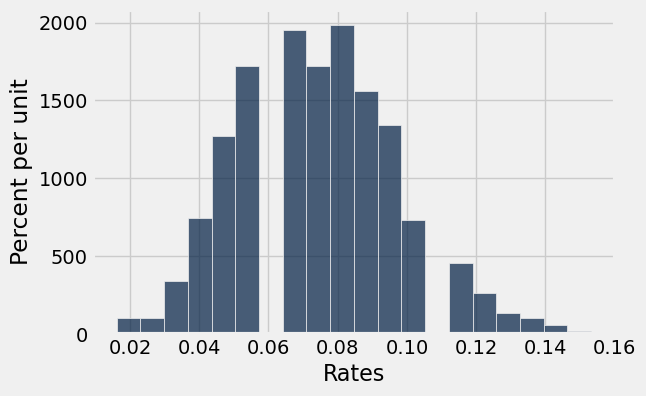

In [100]:
simulations = 1000
simulated_rates = make_array()
for i in np.arange(simulations):
    simulated_rates = np.append(simulated_rates, one_simulated_rate())

Table().with_column('Rates', simulated_rates).hist(0, bins=20)

np.count_nonzero(simulated_rates >= 0.11290323) / len(simulated_rates)

# Cereal

In [101]:
cereal = Table.read_table('data/cereal.csv')
cereal

name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
100% Bran,N,C,70,4,1,130,10,5,6,280,25,3,1,0.33,68.403
100% Natural Bran,Q,C,120,3,5,15,2,8,8,135,0,3,1,1,33.9837
All-Bran,K,C,70,4,1,260,9,7,5,320,25,3,1,0.33,59.4255
All-Bran with Extra Fiber,K,C,50,4,0,140,14,8,0,330,25,3,1,0.5,93.7049
Almond Delight,R,C,110,2,2,200,1,14,8,-1,25,3,1,0.75,34.3848
Apple Cinnamon Cheerios,G,C,110,2,2,180,1.5,10.5,10,70,25,1,1,0.75,29.5095
Apple Jacks,K,C,110,2,0,125,1,11,14,30,25,2,1,1,33.1741
Basic 4,G,C,130,3,2,210,2,18,8,100,25,3,1.33,0.75,37.0386
Bran Chex,R,C,90,2,1,200,4,15,6,125,25,1,1,0.67,49.1203
Bran Flakes,P,C,90,3,0,210,5,13,5,190,25,3,1,0.67,53.3138


In [103]:
cereal.select('shelf', 'sugars').group('shelf', np.average)

shelf,sugars average
1,4.8
2,9.61905
3,6.52778


In [104]:
cereal2 = cereal.select('shelf', 'sugars')
cereal2

shelf,sugars
3,6
3,8
3,5
3,0
3,8
1,10
2,14
3,8
1,6
3,5


In [116]:
cereal2.with_column(
    'Shuffled Label', cereal2.sample(with_replacement=False).column('shelf')
).select(2, 1).group(0, np.average).column(1).item(1)

6.476190476190476

0.0005

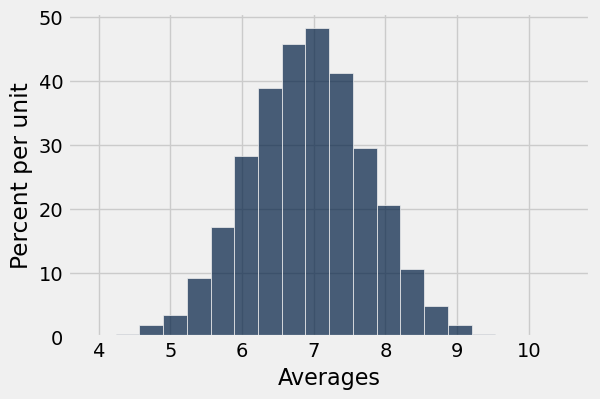

In [118]:
def one_simulated_average():
    return cereal2.with_column(
        'Shuffled Label', cereal2.sample(with_replacement=False).column('shelf')
    ).select(2, 1).group(0, np.average).column(1).item(1)

simulations = 10000
simulated_averages = make_array()
for i in np.arange(simulations):
    simulated_averages = np.append(simulated_averages, one_simulated_average())

Table().with_column('Averages', simulated_averages).hist(0, bins=20)

np.count_nonzero(simulated_averages >= 9.61905) / len(simulated_averages)